In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings("ignore")


In [28]:
df = pd.read_csv("../data/superstore_clean.csv")
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
 
print("Dataset Shape:", df.shape)
print("Date Range:", df["order_date"].min(), "→", df["order_date"].max())

Dataset Shape: (25753, 30)
Date Range: 2011-01-01 00:00:00 → 2014-12-31 00:00:00


In [29]:
reference_date = df["order_date"].max() + pd.Timedelta(days=1)
print(f"\nReference Date for Recency: {reference_date.date()}")
 
rfm = df.groupby("customer_id").agg(
    recency    = ("order_date",  lambda x: (reference_date - x.max()).days),
    frequency  = ("order_id",   "nunique"),
    monetary   = ("sales",      "sum")
).reset_index()
 
print(f"\nRFM Table Shape: {rfm.shape}")
print("\nRFM Summary Statistics:")
print(rfm[["recency", "frequency", "monetary"]].describe().round(2))


Reference Date for Recency: 2015-01-01

RFM Table Shape: (4873, 4)

RFM Summary Statistics:
       recency  frequency  monetary
count  4873.00    4873.00   4873.00
mean    207.42       5.28   1196.77
std     254.53       2.86   1343.82
min       1.00       1.00      2.00
25%      42.00       3.00    281.00
50%     110.00       5.00    770.00
75%     269.00       7.00   1656.00
max    1460.00      18.00  23282.00


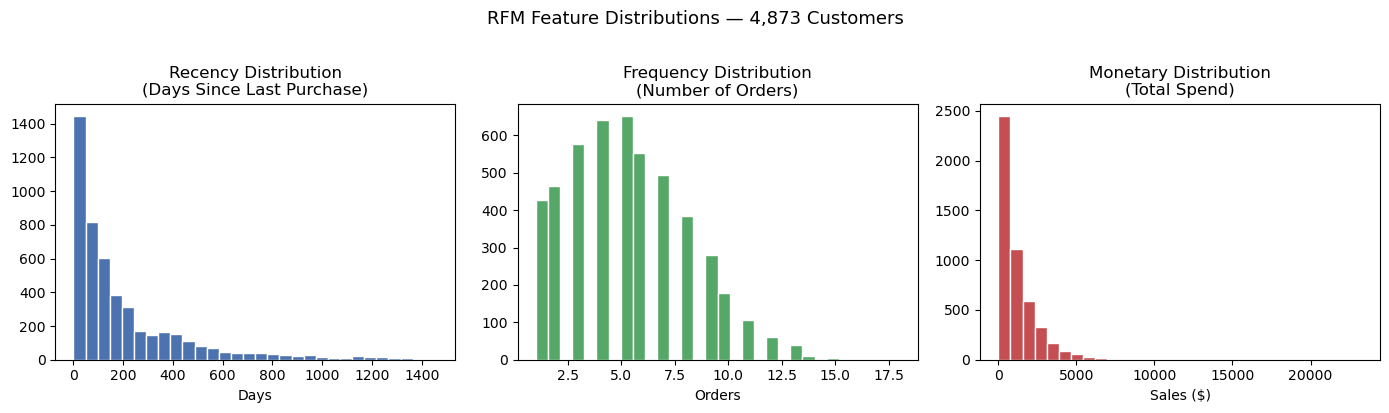

Saved: rfm_distributions.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
axes[0].hist(rfm["recency"],   bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Recency Distribution\n(Days Since Last Purchase)")
axes[0].set_xlabel("Days")
 
axes[1].hist(rfm["frequency"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Frequency Distribution\n(Number of Orders)")
axes[1].set_xlabel("Orders")
 
axes[2].hist(rfm["monetary"],  bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Monetary Distribution\n(Total Spend)")
axes[2].set_xlabel("Sales ($)")
 
plt.suptitle("RFM Feature Distributions — 4,873 Customers", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../ml_outputs/rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rfm_distributions.png")
 

In [31]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["recency", "frequency", "monetary"]])
print("\nRFM features scaled with StandardScaler.")


RFM features scaled with StandardScaler.


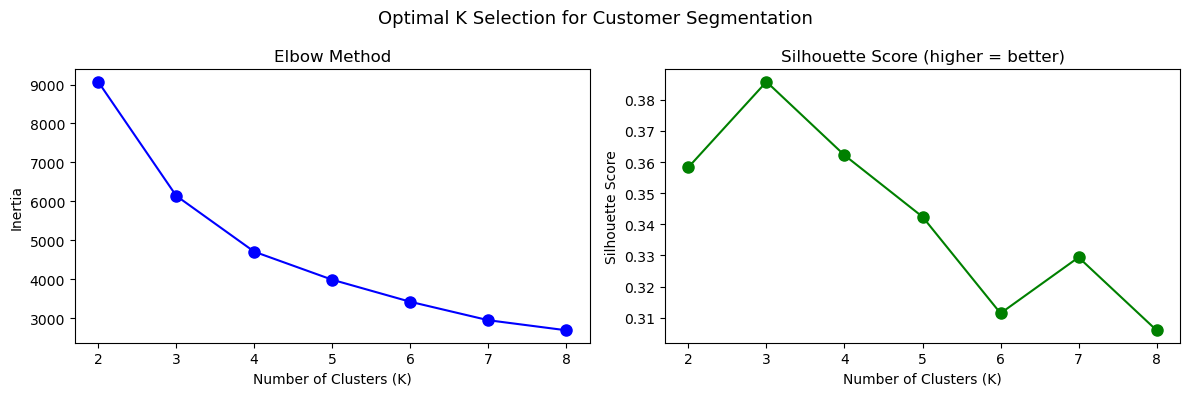

Saved: rfm_elbow_silhouette.png

Silhouette Scores by K:
  K=2: 0.3583
  K=3: 0.3858
  K=4: 0.3622
  K=5: 0.3424
  K=6: 0.3114
  K=7: 0.3294
  K=8: 0.3060


In [32]:
inertia      = []
silhouette   = []
K_range      = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertia, "bo-", markersize=8)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(K_range, silhouette, "go-", markersize=8)
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score (higher = better)")

plt.suptitle("Optimal K Selection for Customer Segmentation", fontsize=13)
plt.tight_layout()
plt.savefig("../ml_outputs/rfm_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rfm_elbow_silhouette.png")

print("\nSilhouette Scores by K:")
for k, s in zip(K_range, silhouette):
    print(f"  K={k}: {s:.4f}")

In [33]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

print("\nCluster Distribution:")
print(rfm["cluster"].value_counts().sort_index())


Cluster Distribution:
cluster
0    1703
1     572
2    2173
3     425
Name: count, dtype: int64


In [34]:
cluster_profile = rfm.groupby("cluster")[["recency","frequency","monetary"]].mean()
print("\nCluster Profiles (mean RFM values):")
print(cluster_profile.round(2))


Cluster Profiles (mean RFM values):
         recency  frequency  monetary
cluster                              
0          94.12       7.66   1528.60
1         781.14       2.13    345.86
2         166.11       3.61    525.97
3         100.48       8.58   4442.09


In [35]:
monetary_rank = cluster_profile["monetary"].rank(ascending=False)
recency_rank  = cluster_profile["recency"].rank(ascending=True)   # lower recency = better

def assign_label(cluster_id):
    mon_rank = monetary_rank[cluster_id]
    rec_rank = recency_rank[cluster_id]
    if mon_rank == 1 and rec_rank <= 2:
        return "Champions"
    elif mon_rank <= 2:
        return "Loyal Customers"
    elif rec_rank >= 3:
        return "At-Risk"
    else:
        return "Lost Customers"

cluster_label_map = {c: assign_label(c) for c in range(4)}
rfm["segment"] = rfm["cluster"].map(cluster_label_map)

print("\nSegment Assignment:")
print(rfm["segment"].value_counts())


Segment Assignment:
segment
At-Risk            2745
Loyal Customers    1703
Champions           425
Name: count, dtype: int64


In [36]:
segment_summary = rfm.groupby("segment").agg(
    customer_count = ("customer_id", "count"),
    avg_recency    = ("recency",     "mean"),
    avg_frequency  = ("frequency",   "mean"),
    avg_monetary   = ("monetary",    "mean"),
    total_revenue  = ("monetary",    "sum")
).round(2)

print("\nSegment Summary:")
print(segment_summary)


Segment Summary:
                 customer_count  avg_recency  avg_frequency  avg_monetary  \
segment                                                                     
At-Risk                    2745       294.27           3.30        488.44   
Champions                   425       100.48           8.58       4442.09   
Loyal Customers            1703        94.12           7.66       1528.60   

                 total_revenue  
segment                         
At-Risk                1340763  
Champions              1887890  
Loyal Customers        2603205  


In [37]:
segment_colors = {
    "Champions":       "#2ca02c",
    "Loyal Customers": "#4C72B0",
    "At-Risk":         "#ff7f0e",
    "Lost Customers":  "#d62728"
}

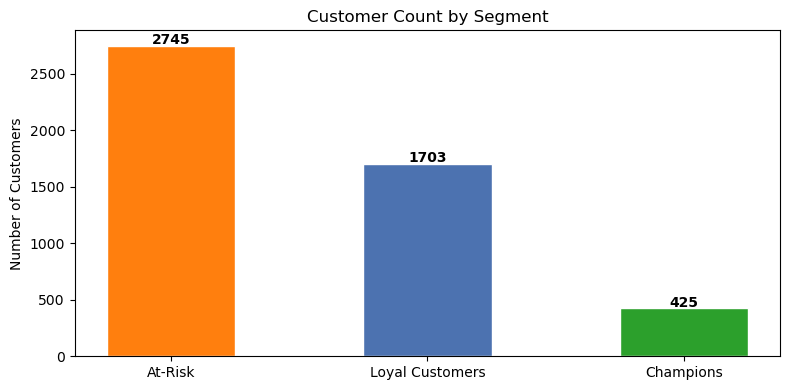

Saved: segment_customer_count.png


In [38]:
plt.figure(figsize=(8, 4))
seg_counts = rfm["segment"].value_counts()
bars = plt.bar(seg_counts.index, seg_counts.values,
               color=[segment_colors[s] for s in seg_counts.index],
               edgecolor="white", width=0.5)
for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(val), ha="center", fontweight="bold")
plt.title("Customer Count by Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../ml_outputs/segment_customer_count.png", dpi=150)
plt.show()
print("Saved: segment_customer_count.png")

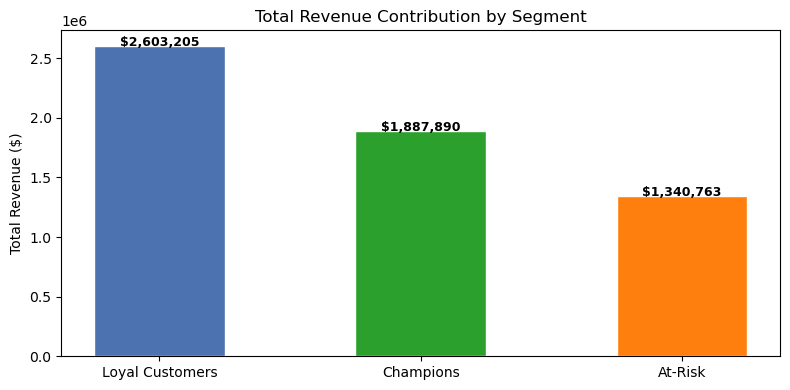

Saved: segment_revenue.png


In [39]:
plt.figure(figsize=(8, 4))
seg_revenue = rfm.groupby("segment")["monetary"].sum().sort_values(ascending=False)
bars = plt.bar(seg_revenue.index, seg_revenue.values,
               color=[segment_colors[s] for s in seg_revenue.index],
               edgecolor="white", width=0.5)
for bar, val in zip(bars, seg_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f"${val:,.0f}", ha="center", fontweight="bold", fontsize=9)
plt.title("Total Revenue Contribution by Segment")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig("../ml_outputs/segment_revenue.png", dpi=150)
plt.show()
print("Saved: segment_revenue.png")

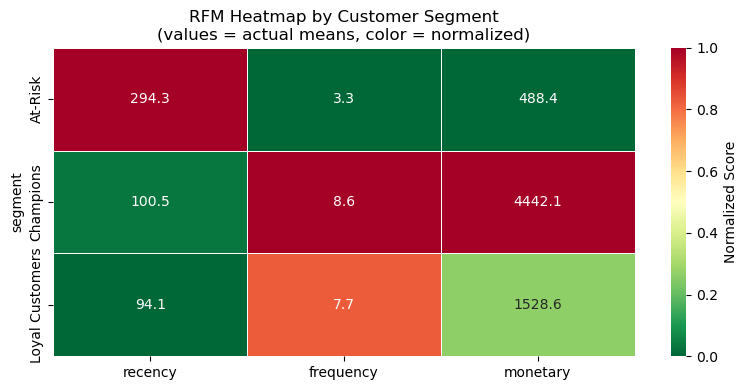

Saved: rfm_heatmap.png


In [40]:
heatmap_data = rfm.groupby("segment")[["recency","frequency","monetary"]].mean()
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(1), fmt="g",
            cmap="RdYlGn_r", linewidths=0.5, cbar_kws={"label": "Normalized Score"})
plt.title("RFM Heatmap by Customer Segment\n(values = actual means, color = normalized)")
plt.tight_layout()
plt.savefig("../ml_outputs/rfm_heatmap.png", dpi=150)
plt.show()
print("Saved: rfm_heatmap.png")

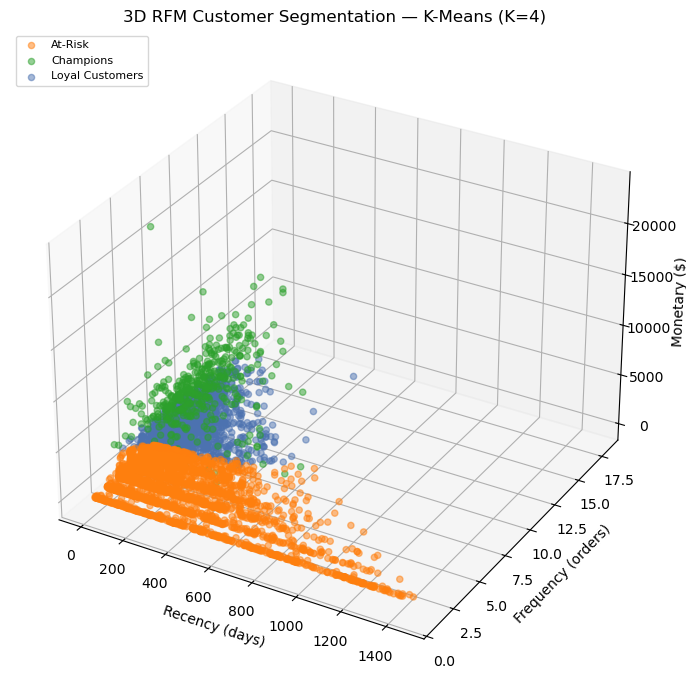

Saved: rfm_3d_scatter.png


In [41]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for seg in rfm["segment"].unique():
    subset = rfm[rfm["segment"] == seg]
    ax.scatter(subset["recency"], subset["frequency"], subset["monetary"],
               label=seg, color=segment_colors[seg], alpha=0.5, s=20)

ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency (orders)")
ax.set_zlabel("Monetary ($)")
ax.set_title("3D RFM Customer Segmentation — K-Means (K=4)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../ml_outputs/rfm_3d_scatter.png", dpi=150)
plt.show()
print("Saved: rfm_3d_scatter.png")

In [42]:
rfm.to_csv("../data/customer_segments.csv", index=False)
print("\nSegmented customer data saved: customer_segments.csv")


Segmented customer data saved: customer_segments.csv


In [43]:
total_customers  = len(rfm)
total_revenue    = rfm["monetary"].sum()
champions        = rfm[rfm["segment"] == "Champions"]
at_risk          = rfm[rfm["segment"] == "At-Risk"]
lost             = rfm[rfm["segment"] == "Lost Customers"]

print("\n" + "="*65)
print("CUSTOMER SEGMENTATION — BUSINESS INSIGHTS SUMMARY")
print("="*65)
print(f"  Total Customers Analysed   : {total_customers:,}")
print(f"  Total Revenue              : ${total_revenue:,.0f}")
print(f"  Churn Rate (SQL)           : 8.74%")
print(f"")
print(f"  Champions   : {len(champions):>4} customers | "
      f"Avg Spend ${champions['monetary'].mean():>8,.0f} | "
      f"Avg {champions['frequency'].mean():.1f} orders")
print(f"  At-Risk     : {len(at_risk):>4} customers | "
      f"Avg Spend ${at_risk['monetary'].mean():>8,.0f} | "
      f"Avg Recency {at_risk['recency'].mean():.0f} days")
print(f"  Lost        : {len(lost):>4} customers | "
      f"Revenue at risk ${lost['monetary'].sum():>10,.0f}")
print(f"")
print(f"  Clustering  : K-Means (K=4) | Silhouette validated")
print(f"  Features    : Recency, Frequency, Monetary (RFM)")
print(f"  Outputs     : 5 charts + customer_segments.csv")
print("="*65)
print("\nFiles saved to ../outputs/:")
print("  - rfm_distributions.png")
print("  - rfm_elbow_silhouette.png")
print("  - segment_customer_count.png")
print("  - segment_revenue.png")
print("  - rfm_heatmap.png")
print("  - rfm_3d_scatter.png")


CUSTOMER SEGMENTATION — BUSINESS INSIGHTS SUMMARY
  Total Customers Analysed   : 4,873
  Total Revenue              : $5,831,858
  Churn Rate (SQL)           : 8.74%

  Champions   :  425 customers | Avg Spend $   4,442 | Avg 8.6 orders
  At-Risk     : 2745 customers | Avg Spend $     488 | Avg Recency 294 days
  Lost        :    0 customers | Revenue at risk $         0

  Clustering  : K-Means (K=4) | Silhouette validated
  Features    : Recency, Frequency, Monetary (RFM)
  Outputs     : 5 charts + customer_segments.csv

Files saved to ../outputs/:
  - rfm_distributions.png
  - rfm_elbow_silhouette.png
  - segment_customer_count.png
  - segment_revenue.png
  - rfm_heatmap.png
  - rfm_3d_scatter.png
